# EncodingModel (Analysis 3) — demo on V1

Runs the running-modulation encoding model end-to-end on a **V1 (VISp)** cohort pulled from the
Allen Brain Observatory, matching the main report ([`doc/EncodingModel.md`](doc/EncodingModel.md)).
It shows the **two metrics** that diverge:

- the strict **cross-validated single-trial ΔR²** (the encoding model), and
- the **population-mean running gain** (running vs stationary rate ratio — the metric the reference
  papers use).

**Run in the `allensdk` kernel, from the repo root.** The first run downloads a few Allen NWB / event
files (cached to `boc/`).

In [1]:
%load_ext autoreload
%autoreload 2
import warnings; warnings.filterwarnings("ignore")
import numpy as np, matplotlib.pyplot as plt
import utils
from utils import EncodingModel
from allensdk.core.brain_observatory_cache import BrainObservatoryCache

boc = BrainObservatoryCache(manifest_file="boc/manifest.json")

## 1. Pull a V1 container

Cux2-CreERT2 / upper-layer (L2/3–4) / 175 µm — matched to the report's cohort. We assemble a `data`
dict in the same shape `load_data()` returns (dF/F for cells matched across sessions A/B), so the rest
of the pipeline is untouched.

In [2]:
CID = 511507650
cont = next(c for c in boc.get_experiment_containers() if c["id"] == CID)
print(f"container {CID}: area={cont['targeted_structure']}, depth={cont['imaging_depth']} um, cre={cont['cre_line']}")
exps = boc.get_ophys_experiments(experiment_container_ids=[CID])
EXP = {("A" if "A" in e["session_type"] else "B" if "B" in e["session_type"] else "C"): e["id"] for e in exps}

def build_session(sk, eid):
    ds = boc.get_ophys_experiment_data(eid)
    ts, dff = ds.get_dff_traces()
    dxcm, _ = ds.get_running_speed()
    n = min(len(ts), dff.shape[1], len(dxcm))
    rs = np.zeros((2, n)); rs[0] = np.nan_to_num(dxcm[:n])                # (2, T): row 0 = speed
    stims = {"A": ["drifting_gratings"], "B": ["static_gratings", "natural_scenes"]}[sk]
    d = dict(session_type=sk, t=np.asarray(ts)[:n], dff=np.asarray(dff)[:, :n],
             running_speed=rs, stim_epoch_table=ds.get_stimulus_epoch_table(),
             stim_tables={s: ds.get_stimulus_table(s) for s in stims})
    return d, np.asarray(ds.get_cell_specimen_ids())

SA, cA = build_session("A", EXP["A"])          # drifting gratings
SB, cB = build_session("B", EXP["B"])          # static gratings + natural scenes
matched = np.intersect1d(cA, cB)               # cells tracked across both sessions
iA = {c: i for i, c in enumerate(cA)}; iB = {c: i for i, c in enumerate(cB)}
SA["dff"] = SA["dff"][[iA[c] for c in matched]]
SB["dff"] = SB["dff"][[iB[c] for c in matched]]
data = {"sessions": {"A": SA, "B": SB}, "matched_cell_ids": matched}
print(f"cells matched across sessions A/B: n={len(matched)}")

container 511507650: area=VISp, depth=175 um, cre=Cux2-CreERT2


cells matched across sessions A/B: n=91


## 2. Run the EncodingModel pipeline

`extract_trials` → `EncodingModel(td).fit_all(cv="blocked")` → `r2_decomposition()`. Blocked
(leakage-free) cross-validation is the default; a shuffled K-fold would leak calcium autocorrelation
and inflate ΔR² for the ~0.27 s-spaced sg/ns trials (report §3, §8).

In [3]:
STIM = ["drifting_gratings", "static_gratings", "natural_scenes", "spontaneous"]
fits = {}
print(f"{'stimulus':18s}  ΔR²_add    ΔR²_mult   ΔR²_full   (median across cells, blocked CV)")
for stim in STIM:
    td = utils.extract_trials(data, stim, response_window=None)
    em = EncodingModel(td, n_basis=5).fit_all(cv="blocked")
    da, dm, df = em.r2_decomposition()
    fits[stim] = (td, em)
    print(f"{stim:18s}  {np.median(da):+.4f}  {np.median(dm):+.4f}  {np.median(df):+.4f}")

stimulus            ΔR²_add    ΔR²_mult   ΔR²_full   (median across cells, blocked CV)


drifting_gratings   +0.0071  -0.0023  +0.0021


static_gratings     +0.0013  -0.0023  -0.0013


natural_scenes      +0.0005  -0.0023  -0.0019


spontaneous         -0.0004  -0.0004  -0.0004


### ΔR² decomposition — `plot_r2_decomposition()`

The built-in plot method, one panel per stimulus (composed via `ax=`).

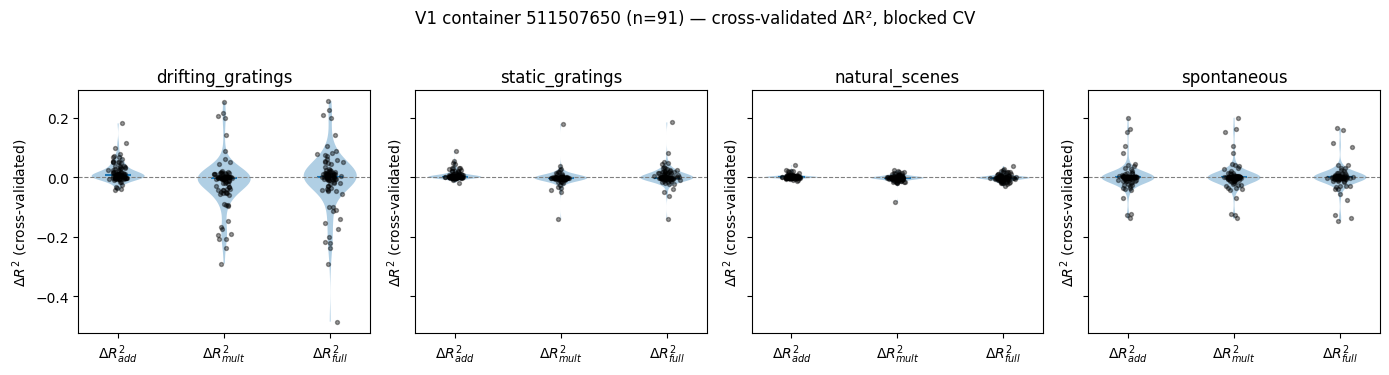

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), sharey=True)
for ax, stim in zip(axes, STIM):
    fits[stim][1].plot_r2_decomposition(ax=ax)
fig.suptitle(f"V1 container {CID} (n={len(matched)}) — cross-validated ΔR², blocked CV", y=1.03)
fig.tight_layout(); plt.show()

## 3. The second metric — population-mean running gain

The metric the reference papers use: mean response on running trials (V > 3 cm/s) vs stationary
(V < 0.5). On the **same cells** this is clearly > 1 (running boosts responses) — even though the
single-trial ΔR² above is ~0. That divergence is the point (report §7.3).

In [5]:
def rate_ratio(td, run_thr=3, still_thr=0.5):
    R = td.responses.mean(2); V = td.running_speed.mean(1)
    mr, ms = R[:, V > run_thr].mean(1), R[:, V < still_thr].mean(1)
    r = (mr / ms)[ms > 0]
    return np.exp(np.nanmean(np.log(r[np.isfinite(r) & (r > 0)])))

for stim in ["drifting_gratings", "static_gratings", "natural_scenes"]:
    print(f"{stim:18s}  running/stationary rate ratio = {rate_ratio(fits[stim][0]):.2f}")

drifting_gratings   running/stationary rate ratio = 2.14
static_gratings     running/stationary rate ratio = 1.88
natural_scenes      running/stationary rate ratio = 3.78


## 4. The pooled result (3 V1 containers, n = 363)

This one container illustrates the pipeline; the report's headline **pools 3 V1 containers** via
`scripts/v1_report.py` (cached in `data/encoding_v1.npz`). A large single-container drifting-gratings
ΔR²_add does **not** survive pooling — always pool before trusting the strict metric.

In [6]:
Z = np.load("data/encoding_v1.npz", allow_pickle=True)
n_pool = len(Z["dff__natural_scenes__full"])
print(f"Pooled V1, n={n_pool} cells across 3 containers:")
print(f"{'stimulus':18s}  ΔR²_add median (strict, blocked CV)")
for stim in ["drifting_gratings", "static_gratings", "natural_scenes"]:
    print(f"{stim:18s}  {np.median(Z[f'dff__{stim}__add']):+.4f}")
print("\nPopulation-mean gain for the same cohort (rate ratio 1.57 / 1.72 / 2.15) is shown below.")

Pooled V1, n=363 cells across 3 containers:
stimulus            ΔR²_add median (strict, blocked CV)
drifting_gratings   -0.0001
static_gratings     +0.0002
natural_scenes      +0.0003

Population-mean gain for the same cohort (rate ratio 1.57 / 1.72 / 2.15) is shown below.


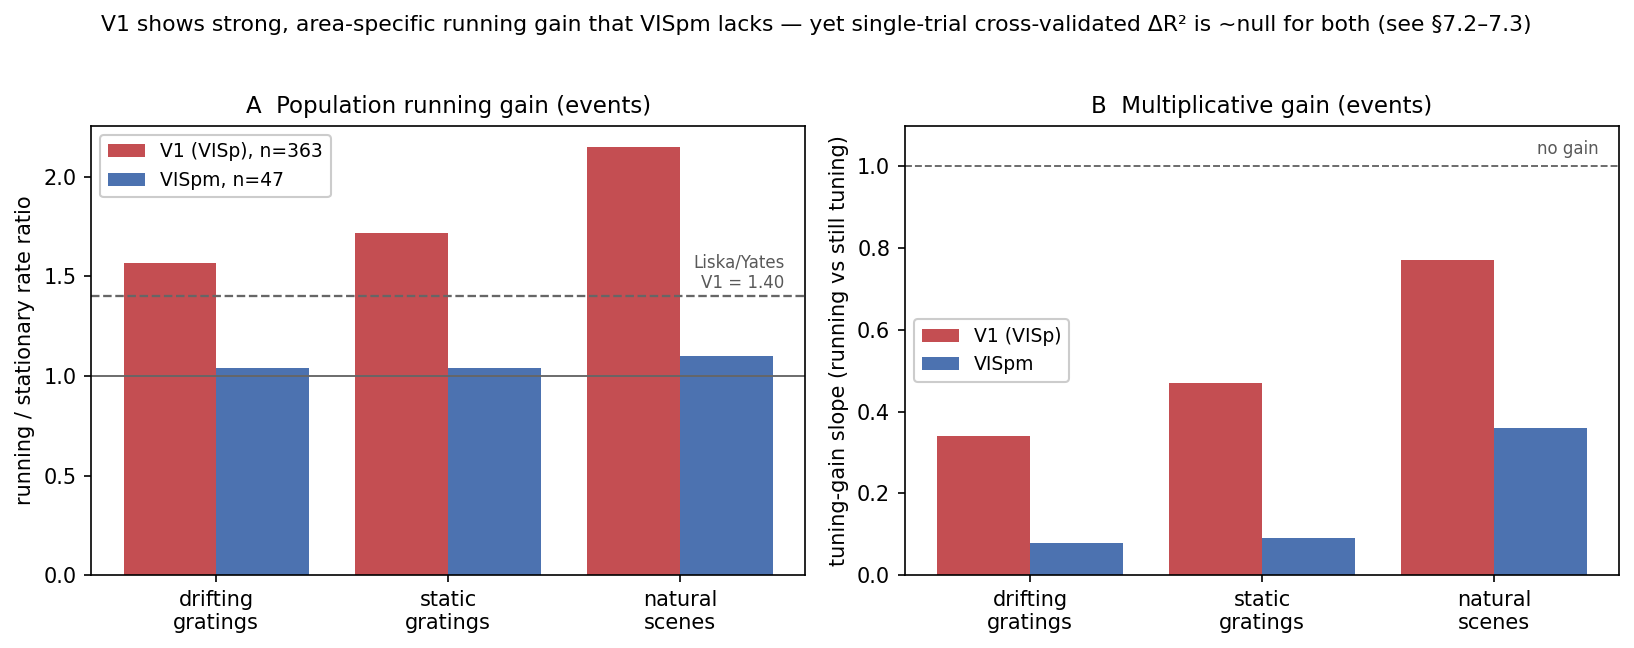

In [7]:
from IPython.display import Image
Image("doc/figures/v1_gain.png")

## Takeaway

**Two metrics diverge.** In V1, running produces a strong, robust, area-specific **population gain**
(rate ratio ≈ 1.5–2.5, matching the locomotion literature), but the strict **cross-validated
single-trial ΔR²** is ~null — running does not improve *out-of-fold single-trial prediction* on noisy
calcium. See [`doc/EncodingModel.md`](doc/EncodingModel.md) for the full analysis (incl. the CV-leakage
fix and the VISpm→V1 area finding) and [`doc/TEAM_NOTE.md`](doc/TEAM_NOTE.md) for the summary.